# 03 - KPI et pilotage de l’activité

## Objectif
Ce notebook a pour but de produire des indicateurs de pilotage simples et actionnables sur :
- les ventes,
- les clients,
- les produits,
- les dépenses,
- le budget.

In [5]:
# Cette cellule importe les bibliothèques nécessaires aux KPI et graphiques.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Cette cellule charge les données nettoyées.
df_client = pd.read_csv("Data/processed/clean_client.csv")
df_produit = pd.read_csv("Data/processed/clean_produit.csv")
df_vente = pd.read_csv("Data/processed/clean_vente.csv")
df_depence = pd.read_csv("Data/processed/clean_depence.csv")
df_budget = pd.read_csv("Data/processed/clean_budget.csv")
df_categorie = pd.read_csv("Data/processed/clean_categorie.csv")

In [4]:
# Cette cellule prépare les dates pour les agrégations mensuelles.

df_vente["date"] = pd.to_datetime(df_vente["date"], errors="coerce")
df_depence["date"] = pd.to_datetime(df_depence["date"], errors="coerce")
df_budget["month"] = pd.to_datetime(df_budget["month"], errors="coerce")

df_vente["month"] = df_vente["date"].dt.to_period("M").dt.to_timestamp()
df_depence["month"] = df_depence["date"].dt.to_period("M").dt.to_timestamp()
df_budget["month"] = df_budget["month"].dt.to_period("M").dt.to_timestamp()

KPI globaux

In [5]:
# Cette cellule calcule les principaux KPI globaux.

ca_total = df_vente["total_eur"].sum()
nb_factures = df_vente["invoice_id"].nunique()
panier_moyen = df_vente["total_eur"].mean()
nb_clients = df_vente["customer_id"].nunique()
dep_total = df_depence["amount_mad"].sum()
budget_total = df_budget["budget_amount_mad"].sum()

print("CA total (EUR) :", round(ca_total, 2))
print("Nombre de factures :", nb_factures)
print("Panier moyen (EUR) :", round(panier_moyen, 2))
print("Nombre de clients actifs :", nb_clients)
print("Dépenses totales (MAD) :", round(dep_total, 2))
print("Budget total (MAD) :", round(budget_total, 2))

CA total (EUR) : 23110957.64
Nombre de factures : 26121
Panier moyen (EUR) : 884.77
Nombre de clients actifs : 120
Dépenses totales (MAD) : 15255357.06
Budget total (MAD) : 7787287.62


## Interprétation
Ces KPI donnent une vue d’ensemble de l’activité.

À commenter :
- le CA total mesure la performance commerciale globale ;
- le panier moyen renseigne sur la valeur moyenne des transactions ;
- le nombre de clients actifs indique l’étendue de la base réellement exploitée ;
- les dépenses et budgets doivent être lus séparément des ventes car ils sont exprimés dans une autre devise.

KPI mensuels

In [6]:
# Cette cellule construit les agrégats mensuels principaux.

ca_month = df_vente.groupby("month", as_index=False)["total_eur"].sum()
dep_month = df_depence.groupby("month", as_index=False)["amount_mad"].sum()
bud_month = df_budget.groupby("month", as_index=False)["budget_amount_mad"].sum()

display(ca_month.head())
display(dep_month.head())
display(bud_month.head())

,month,total_eur
0,2019-01-01,270325.26
1,2019-02-01,241463.08
2,2019-03-01,267569.89
3,2019-04-01,296383.88
4,2019-05-01,274617.63


,month,amount_mad
0,2019-01-01,199906.63
1,2019-02-01,108928.18
2,2019-03-01,214365.18
3,2019-04-01,158205.22
4,2019-05-01,194285.47


,month,budget_amount_mad
0,2019-01-01,82532.38
1,2019-02-01,80947.61
2,2019-03-01,82181.45
3,2019-04-01,79772.87
4,2019-05-01,87732.32


## Interprétation
Les indicateurs mensuels permettent de suivre la dynamique dans le temps.

À commenter :
- ils servent à détecter des hausses, baisses ou ruptures de tendance ;
- ils facilitent la comparaison entre périodes ;
- ils sont essentiels pour le pilotage opérationnel.

In [7]:
# Cette cellule compare les dépenses mensuelles au budget mensuel.

budget_vs = bud_month.merge(dep_month, on="month", how="outer").fillna(0)
budget_vs["variance_mad"] = budget_vs["amount_mad"] - budget_vs["budget_amount_mad"]
budget_vs["variance_pct"] = np.where(
    budget_vs["budget_amount_mad"] == 0,
    np.nan,
    budget_vs["variance_mad"] / budget_vs["budget_amount_mad"]
)

display(budget_vs)

,month,budget_amount_mad,amount_mad,variance_mad,variance_pct
0,2019-01-01,82532.38,199906.63,117374.25,1.422160
1,2019-02-01,80947.61,108928.18,27980.57,0.345663
2,2019-03-01,82181.45,214365.18,132183.73,1.608438
3,2019-04-01,79772.87,158205.22,78432.35,0.983196
4,2019-05-01,87732.32,194285.47,106553.15,1.214526
...,...,...,...,...,...
79,2025-08-01,98002.20,211669.56,113667.36,1.159845
80,2025-09-01,102486.57,159771.47,57284.90,0.558950
81,2025-10-01,104755.40,203331.41,98576.01,0.941011
82,2025-11-01,102660.54,154807.89,52147.35,0.507959


## Interprétation
Cette comparaison permet d’identifier les mois en dépassement ou sous-consommation budgétaire.

À commenter :
- une variance positive indique un dépassement de budget ;
- une variance négative indique des dépenses inférieures au prévu ;
- cet indicateur est central pour le contrôle de gestion.

In [8]:
# Cette cellule identifie les clients les plus contributeurs.

top_clients = (
    df_vente.groupby("customer_id", as_index=False)["total_eur"]
    .sum()
    .sort_values("total_eur", ascending=False)
    .head(10)
)

display(top_clients)

,customer_id,total_eur
8,C0009,244290.36
86,C0087,236122.28
77,C0078,235374.23
50,C0051,230451.43
102,C0103,227945.31
29,C0030,227548.50
42,C0043,226721.83
76,C0077,226289.95
55,C0056,224059.95
62,C0063,220202.45


## Interprétation
Ce classement met en évidence les clients les plus importants en valeur.

À commenter :
- il aide à identifier les comptes stratégiques ;
- une trop forte concentration peut créer un risque de dépendance ;
- ces clients doivent faire l’objet d’un suivi spécifique.

In [9]:
# Cette cellule identifie les produits les plus contributeurs.

top_products = (
    df_vente.groupby("product_id", as_index=False)["total_eur"]
    .sum()
    .sort_values("total_eur", ascending=False)
    .head(10)
)

display(top_products)

,product_id,total_eur
25,P026,1763006.62
7,P008,1732189.83
17,P018,1551778.67
32,P033,1513404.31
30,P031,1360680.06
19,P020,1113972.92
20,P021,1111135.78
28,P029,977849.05
4,P005,868726.49
0,P001,747633.71


## Interprétation
Ce tableau montre quels produits génèrent le plus de valeur.

À commenter :
- les produits en tête constituent les moteurs de chiffre d’affaires ;
- ils peuvent être prioritaires dans la stratégie commerciale ;
- il est utile de surveiller leur dépendance dans le mix produit.

In [10]:
# Cette cellule mesure le chiffre d'affaires par segment client.

df_sales_seg = df_vente.merge(df_client[["customer_id", "segment"]], on="customer_id", how="left")
ca_segment = df_sales_seg.groupby("segment", as_index=False)["total_eur"].sum().sort_values("total_eur", ascending=False)

display(ca_segment)

,segment,total_eur
1,Retail,11595721.33
2,SMB,7808011.84
0,Enterprise,3707224.47


## Interprétation
Cet indicateur permet de comparer la contribution des différents segments de clientèle.

À commenter :
- il aide à identifier les segments dominants ;
- il peut orienter la stratégie de ciblage ;
- il est utile de le comparer ensuite à la rentabilité si la conversion de devise est disponible.

In [11]:
# Cette cellule mesure le chiffre d'affaires par pays.

df_sales_country = df_vente.merge(df_client[["customer_id", "country_iso3"]], on="customer_id", how="left")
ca_country = df_sales_country.groupby("country_iso3", as_index=False)["total_eur"].sum().sort_values("total_eur", ascending=False)

display(ca_country)

,country_iso3,total_eur
6,MAR,7535711.98
4,FRA,3979008.44
8,USA,3914128.75
5,GBR,2149167.79
1,DEU,1525275.61
7,SEN,1153223.65
2,DZA,1129155.24
0,CAN,1111972.12
3,ESP,613314.06


## Interprétation
Cette lecture géographique montre les marchés les plus importants.

À commenter :
- elle permet d’identifier les pays les plus contributeurs ;
- elle aide à repérer une concentration géographique éventuelle ;
- elle peut guider les priorités d’expansion ou de sécurisation commerciale.

In [12]:
# Cette cellule agrège les dépenses par département.

dep_dept = df_depence.groupby("department", as_index=False)["amount_mad"].sum().sort_values("amount_mad", ascending=False)
display(dep_dept)

,department,amount_mad
5,RH,9375935.87
4,Operations,1705611.82
1,Facilities,1557863.15
3,IT,1051097.81
0,Admin,1042871.36
2,Growth,521977.05


## Interprétation
Cet indicateur identifie les départements les plus consommateurs de budget.

À commenter :
- il permet de cibler les zones de coût les plus importantes ;
- il aide à prioriser les analyses de dérive budgétaire ;
- un département fortement dépensier n’est pas forcément problématique, mais mérite une lecture plus fine.

In [13]:
# Cette cellule agrège les dépenses par type de charge.

dep_type = df_depence.groupby("type", as_index=False)["amount_mad"].sum().sort_values("amount_mad", ascending=False)
display(dep_type)

,type,amount_mad
0,Fixed,10912996.74
1,Variable,4342360.32


## Interprétation
Cette vue permet de comprendre la structure globale des coûts.

À commenter :
- elle montre le poids relatif des charges fixes et variables ;
- une structure trop rigide peut réduire la flexibilité de l’entreprise ;
- une part variable élevée peut être plus facile à ajuster à court terme.

In [14]:
# Cette cellule identifie les fournisseurs les plus coûteux.

top_vendors = (
    df_depence.groupby("vendor", as_index=False)["amount_mad"]
    .sum()
    .sort_values("amount_mad", ascending=False)
    .head(10)
)

display(top_vendors)

,vendor,amount_mad
13,Payroll,9375935.87
11,Office landlord,1332691.56
9,Microsoft,484971.42
0,AWS,468358.41
4,Google,459919.04
6,Local supplier,347892.46
5,KPMG,335328.19
1,Air Maroc,321616.24
2,DHL,321545.43
7,Maroc Telecom,319144.99


## Interprétation
Ce classement met en évidence les fournisseurs les plus importants en coût.

À commenter :
- il permet d’identifier les partenaires critiques ;
- il peut révéler un risque de dépendance fournisseur ;
- il est utile pour prioriser les actions de négociation ou d’optimisation des achats.

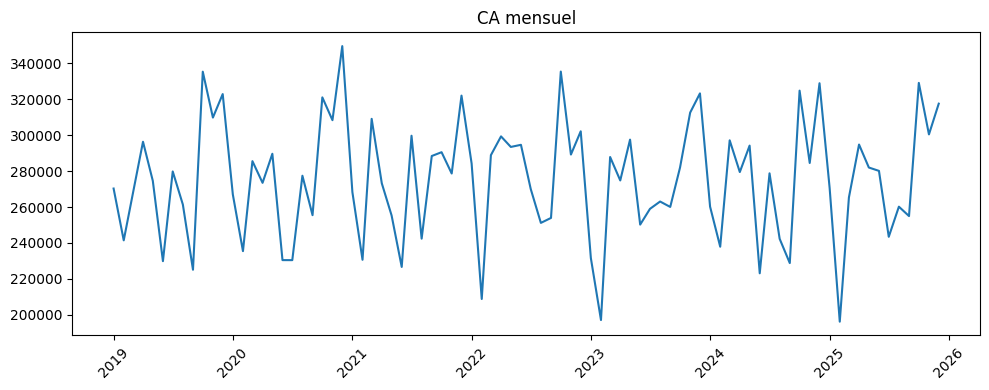

In [15]:
# Cette cellule affiche l'évolution mensuelle du chiffre d'affaires.

plt.figure(figsize=(10, 4))
plt.plot(ca_month["month"], ca_month["total_eur"])
plt.title("CA mensuel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interprétation
Ce graphique permet de visualiser la tendance commerciale dans le temps.

À commenter :
- une tendance haussière traduit une croissance de l’activité ;
- des variations brutales peuvent signaler une saisonnalité ou des événements exceptionnels ;
- ce visuel est un support central de pilotage commercial.

## Synthèse finale
Les principaux enseignements KPI sont les suivants :
- le chiffre d’affaires global et mensuel permettent de suivre la dynamique commerciale ;
- les top clients, top produits et segments montrent les moteurs principaux de l’activité ;
- le budget vs réalisé permet de suivre la discipline de dépense ;
- les analyses par département, type de charge et fournisseur aident au pilotage des coûts ;
- une limite importante subsiste : les ventes sont en EUR alors que dépenses et budgets sont en MAD, ce qui empêche une analyse consolidée de marge sans conversion préalable.